# The taper element

A `Taper` is a conical transition between two bore radii. It is what you put
between sections of a beam line that do not share an aperture — a narrow
external beam pipe and a wider cavity bore, say.

Two elements whose apertures differ can be concatenated directly — the junction
closes with an abrupt radial step, which is a real structure. `cavsim2d` builds
it and tells you where it is, so an accidental step does not pass unnoticed. A
taper is the gradual alternative, and its wall angle is the quantity a wakefield
or trapped-mode study is sensitive to.

This notebook is live: every figure below is produced by running `cavsim2d`.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

from cavsim2d import Assembly, Beampipe, Taper
from cavsim2d.utils.style import apply_style, WARM

apply_style()
workspace = tempfile.mkdtemp()

## 1. The parameterisation

| parameter | meaning |
| --- | --- |
| `R_left`, `R_right` | bore radius at the upstream and downstream ends |
| `L` | overall element length |
| `straight_left`, `straight_right` | straight runs of pipe before and after the cone (default 0) |
| `R_fillet` | radius rounding both transition corners (default 0, sharp) |
| `cone_length` | *derived* — `L` minus the two straight runs |
| `half_angle` | *derived* — cone half-angle from the axis, in degrees |

All lengths are in millimetres, as everywhere else in `cavsim2d`.

![Taper parameters](../../_static/beamline_taper_nomenclature.png)

In [2]:
taper = Taper(R_left=40.0, R_right=80.0, L=120.0)

print(f'cone length : {taper.cone_length:.1f} mm')
print(f'half angle  : {taper.half_angle:.2f} deg')
taper.parameters

cone length : 120.0 mm
half angle  : 18.43 deg


{'R_left': 40.0,
 'R_right': 80.0,
 'L': 120.0,
 'straight_left': 0.0,
 'straight_right': 0.0,
 'R_fillet': 0.0}

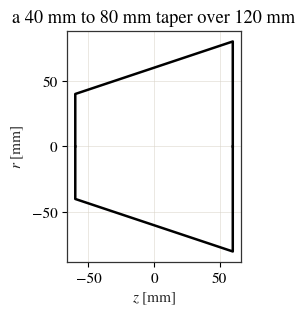

In [3]:
ax = taper.plot('geometry', mirror=True, show=False)
ax.set_title('a 40 mm to 80 mm taper over 120 mm')
plt.show()

## 2. Rounding the transition corners

With no straight runs the cone spans the whole element, so its corners belong to
whatever it is joined to and there is nothing to round — `R_fillet` is ignored
rather than being an error.

Give the element a straight run at each end and the corners become its own, and
`R_fillet` rounds them with an exact arc, tangent to both walls. That is the
same construction the bellows uses for its convolutions.

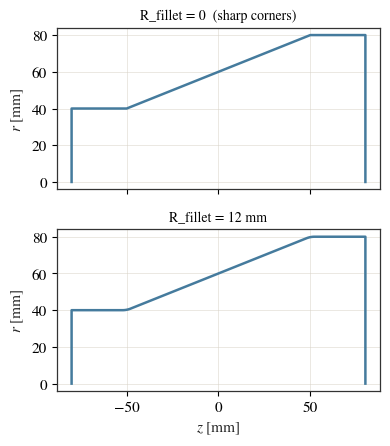

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.6), sharex=True)

sharp = Taper(R_left=40.0, R_right=80.0, L=160.0,
              straight_left=30.0, straight_right=30.0)
round_ = Taper(R_left=40.0, R_right=80.0, L=160.0,
               straight_left=30.0, straight_right=30.0, R_fillet=12.0)

for ax, t, title in zip(axes, (sharp, round_),
                        ('R_fillet = 0  (sharp corners)',
                         'R_fillet = 12 mm')):
    t.plot('geometry', ax=ax, color=WARM[0], show=False)
    ax.set_title(title, fontsize=10)
    ax.legend().remove()
axes[0].set_xlabel('')
plt.tight_layout()
plt.show()

## 3. When a fillet does not fit

A corner radius needs room, on the straight run it sits on and on the cone it
shares with the other corner. Both conditions are checked when you build the
taper, so you get a named constraint immediately rather than a failure later.

In [5]:
nominal = dict(R_left=40.0, R_right=80.0, L=120.0)

cases = [
    dict(straight_left=100.0, straight_right=100.0),
    dict(straight_left=0.5, R_fillet=20.0),
    dict(R_left=40.0, R_right=41.0, L=100.0,
         straight_left=45.0, straight_right=45.0, R_fillet=250.0),
]
for change in cases:
    try:
        Taper(**{**nominal, **change})
    except ValueError as err:
        print(f'{err}\n')

the straight runs (100.0 + 100.0 = 200 mm) exceed the element length L=120.0 mm, leaving no room for the cone.

the left fillet does not fit: it reaches 3.258 mm back along a straight_left of 0.5 mm. Reduce R_fillet, or lengthen straight_left.

the two fillets do not both fit on the 10.05 mm cone: they need 24.94 mm. Reduce R_fillet, or lengthen the taper.



## 4. Joining two bores

Joining two elements whose apertures differ gives an abrupt radial step. That is
a real structure and it is built as asked — but it is also easy to create by
accident and invisible once the walls are joined, so every mismatch is reported
with its axial position and step size.

In [6]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    Beampipe(R=40.0, L=80.0, name='narrow') + Beampipe(R=80.0, L=80.0, name='wide')

for entry in caught:
    print(entry.message)

assembly 'assembly': aperture mismatch at 1 junction, closed with an abrupt radial step:
  z =    40.000 mm : 'narrow' ends at r = 40 mm, 'wide' starts at r = 80 mm  ->  step of +40 mm
If that is intended, pass allow_steps=True to silence this. If not, insert a Taper between the elements, e.g. Taper(R_left=40, R_right=80, L=...).


`check_continuity()` returns the same information as data, if you would rather
inspect it than read it. Pass `allow_steps=True` when the steps are intended, to
silence the warning — or put a taper in between, which is what the element is
for.

steps in `step`: [{'index': 0, 'labels': ('narrow', 'wide'), 'radii': (40.0, 80.0), 'step': 40.0, 'z': 40.0}]


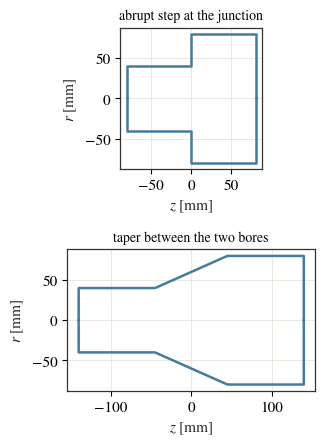

taper half-angle : 23.96 deg over 90 mm


In [7]:
step = Assembly([Beampipe(R=40.0, L=80.0, name='narrow'),
                 Beampipe(R=80.0, L=80.0, name='wide')],
                allow_steps=True, name='step')
print('steps in `step`:', step.check_continuity())

cone = Assembly([Beampipe(R=40.0, L=80.0, name='narrow'),
                 Taper(R_left=40.0, R_right=80.0, L=120.0,
                       straight_left=15.0, straight_right=15.0, R_fillet=8.0),
                 Beampipe(R=80.0, L=80.0, name='wide')], name='cone')

fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.6))
for ax, asm, title in zip(axes, (step, cone),
                          ('abrupt step at the junction',
                           'taper between the two bores')):
    asm.plot('geometry', ax=ax, mirror=True, color=WARM[0], show=False)
    ax.set_title(title, fontsize=10)
    ax.legend().remove()
plt.tight_layout()
plt.show()

t = cone.element('taper')
print(f'taper half-angle : {t.half_angle:.2f} deg over {t.cone_length:.0f} mm')

## 5. How much the transition length matters

Short the structure at both ends and it becomes a resonator, so the transition
geometry shows up as a frequency. Lengthening the taper shallows the angle and
adds volume, and the fundamental follows.

In [8]:
lengths = [40.0, 80.0, 120.0, 160.0]
angles, freqs = [], []

for L in lengths:
    line = Assembly([Beampipe(R=40.0, L=80.0, name='narrow'),
                     Taper(R_left=40.0, R_right=80.0, L=L),
                     Beampipe(R=80.0, L=80.0, name='wide')],
                    ends='pec', name=f'taper_L{L:.0f}')
    line.set_workspace(os.path.join(workspace, line.name))
    line.eigenmode.run({'polarisation': 'monopole', 'n_modes': 2,
                        'boundary_conditions': 'mm',
                        'mesh_config': {'h': 5, 'p': 2}})
    angles.append(line.element('taper').half_angle)
    freqs.append(line.eigenmode.qois['freq [MHz]'])
    print(f'L = {L:5.0f} mm   half_angle = {angles[-1]:5.2f} deg   '
          f'f = {freqs[-1]:9.3f} MHz')

L =    40 mm   half_angle = 45.00 deg   f =  1509.604 MHz


L =    80 mm   half_angle = 26.57 deg   f =  1508.665 MHz


L =   120 mm   half_angle = 18.43 deg   f =  1504.361 MHz


L =   160 mm   half_angle = 14.04 deg   f =  1500.224 MHz


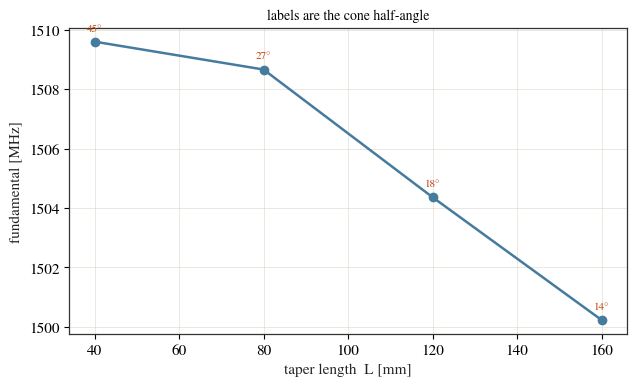

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(lengths, freqs, 'o-', color=WARM[0])
for L, a, f in zip(lengths, angles, freqs):
    ax.annotate(f'{a:.0f}°', xy=(L, f), xytext=(0, 8),
                textcoords='offset points', ha='center',
                fontsize=8, color=WARM[1])
ax.set_xlabel('taper length  L [mm]')
ax.set_ylabel('fundamental [MHz]')
ax.set_title('labels are the cone half-angle', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Wakefield: what the taper is actually for

The resonance above shows the transition changing the geometry. The reason to
taper rather than step is impedance, and that is a wakefield question: drive a
bunch through and measure what it leaves behind.

`wakefield.run` writes an ABCI deck from the same profile. ABCI will not run a
structure without a beam pipe at each end, and left to itself it adds three
times the device's own length — which would grow with the taper and make a
length sweep compare different structures. `beampipe_length` (metres) pins it,
so only the transition changes.

In [10]:
taper_wf = Taper(R_left=35.0, R_right=70.0, L=80.0, name='taper_wake')
taper_wf.set_workspace(os.path.join(workspace, 'taper_wake'))
taper_wf.wakefield.run({'MROT': 2, 'wakelength': 20, 'bunch_length': 25,
                        'beampipe_length': 0.2})      # 200 mm each end
taper_wf.wakefield.qois

{'|k_loss| [V/pC]': 0.008772, '|k_kick| [V/pC/m]': 0.9646}

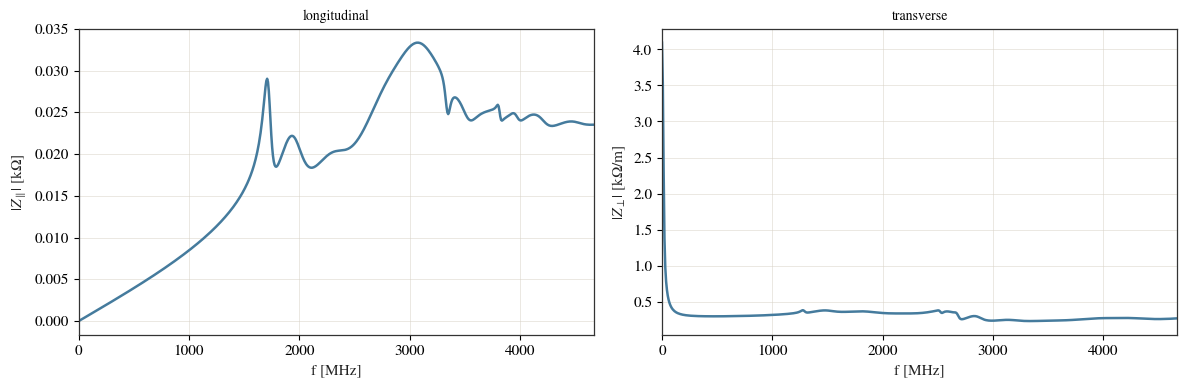

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
taper_wf.wakefield.plot_impedance('longitudinal', ax=a1, show=False)
taper_wf.wakefield.plot_impedance('transverse', ax=a2, show=False)
a1.set_title('longitudinal', fontsize=10)
a2.set_title('transverse', fontsize=10)
plt.tight_layout()
plt.show()

### A shallower taper costs less

Lengthening the transition shallows the wall angle, and the loss and kick
factors fall with it. This is the trade the element exists to make: axial length
against impedance.

In [12]:
wf_lengths = [40.0, 80.0, 160.0]
wf_angles, wf_kloss, wf_kkick = [], [], []

for L in wf_lengths:
    t = Taper(R_left=35.0, R_right=70.0, L=L, name=f'taper_wf_L{L:.0f}')
    t.set_workspace(os.path.join(workspace, t.name))
    t.wakefield.run({'MROT': 2, 'wakelength': 20, 'bunch_length': 25,
                     'beampipe_length': 0.2})         # same pipe at every point
    q = t.wakefield.qois
    wf_angles.append(t.half_angle)
    wf_kloss.append(q['|k_loss| [V/pC]'])
    wf_kkick.append(q['|k_kick| [V/pC/m]'])
    print(f'L = {L:5.0f} mm   half_angle = {wf_angles[-1]:5.2f} deg   '
          f'k_loss = {wf_kloss[-1]:.5f} V/pC   k_kick = {wf_kkick[-1]:.4g} V/pC/m')

L =    40 mm   half_angle = 41.19 deg   k_loss = 0.01878 V/pC   k_kick = 1.427 V/pC/m


L =    80 mm   half_angle = 23.63 deg   k_loss = 0.00877 V/pC   k_kick = 0.9646 V/pC/m


L =   160 mm   half_angle = 12.34 deg   k_loss = 0.00236 V/pC   k_kick = 0.5799 V/pC/m


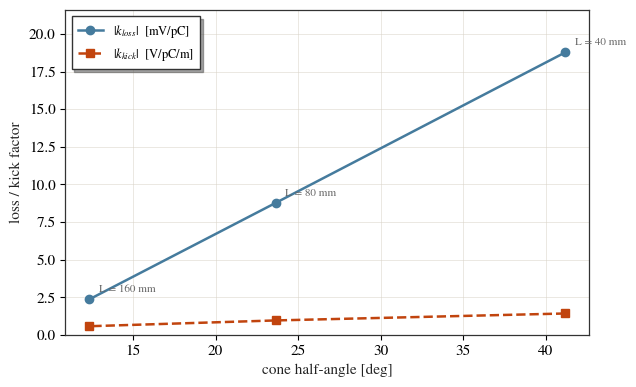

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(wf_angles, np.array(wf_kloss) * 1e3, 'o-', color=WARM[0],
        label=r'$|k_{loss}|$  [mV/pC]')
ax.plot(wf_angles, wf_kkick, 's--', color=WARM[1],
        label=r'$|k_{kick}|$  [V/pC/m]')
for a, k, L in zip(wf_angles, np.array(wf_kloss) * 1e3, wf_lengths):
    ax.annotate(f'L = {L:.0f} mm', xy=(a, k), xytext=(7, 5),
                textcoords='offset points', fontsize=8, color='0.4')
ax.set_xlabel('cone half-angle [deg]')
ax.set_ylabel('loss / kick factor')
ax.set_ylim(0, max(np.array(wf_kloss) * 1e3) * 1.15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Going from a 41° transition to a 12° one drops the loss factor by roughly a
factor of eight. A taper has no features smaller than an ABCI cell, so unlike a
bellows its wake is already converged at the default mesh — refining `DDR` /
`DDZ` moves it by a few per cent (compare the sweep in
[The bellows element](bellows.ipynb)).

## What to take away

* `Taper(R_left, R_right, L)` is a cone; `straight_left` / `straight_right` add
  pipe at each end, and `R_fillet` rounds the two corners that creates.
* `cone_length` and `half_angle` are derived, so you can read the wall angle off
  the object rather than working it out.
* A radius that cannot fit is rejected when you build the taper, by name.
* Use it wherever two elements of different bore should meet gradually. A bare
  mismatch still builds — as a step — and is reported by `check_continuity()`,
  which `allow_steps=True` silences.
* Shallower is cheaper: the loss and kick factors fall steeply as the transition
  lengthens, which is the whole reason to taper rather than step.

See [Assembling a beam line](beam_line_assembly.ipynb) for concatenation itself,
and [A multi-cavity module](multi_cavity_module.ipynb) for a line that uses
tapers to match its external beam pipe to the cavity bore.